## Máster en Big Data y Data Science

### Metodologías de gestión y diseño de proyectos de big data

#### AP2 - Modelado y evaluación

---

En esta libreta se realiza la experimentación para generación del modelo de predicción objetivo del proyecto y la evaluación del mismo.
La versión del dataset a utilizar es la obtenida a partir de las operaciones de transformación.

---

En esta version de la libreta se va a incorporar el registro de los detalles de la experimientacion con la libreria MlFlow

In [28]:
# Se importan las librerías necesarias y se suprimen las advertencias
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore',category=FutureWarning)
warnings.filterwarnings('ignore',category=UserWarning)

En esta version de la libreta se va a incorporar el registro de los detalles de la experimentacion con la libreta MlFlow

In [42]:
import mlflow
import mlflow.sklearn
from datetime import datetime

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("Proyecto 13MBID-ABR2526 - Experimentacion Original")

<Experiment: artifact_location=('file:c:/Users/Usuario/Desktop/universidad big data/Metodologías de gestión y '
 'diseño de proyectos Big '
 'Data/13MBID-Metodologias/notebooks/mlruns/470337362299620174'), creation_time=1772974061719, experiment_id='470337362299620174', last_update_time=1772977687615, lifecycle_stage='active', name='Proyecto 13MBID-ABR2526 - Experimentacion Original', tags={}, workspace='default'>

In [43]:
# Lectura de los datos
df = pd.read_csv('../data/processed/bank-processed.csv')
df.head(5)

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,housemaid,married,basic.4y,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [44]:
# Se divide el dataset en variables predictoras y variable objetivo
X = df.drop('y', axis=1)
y = df['y']

In [45]:
# Se genera el conjunto de entrenamiento y prueba con estratificación
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [46]:
# Se separan las columnas numéricas
numerical_columns=X_train.select_dtypes(exclude='object').columns
display(numerical_columns)

categorical_columns=X_train.select_dtypes(include='object').columns
display(categorical_columns)

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate',
       'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed'],
      dtype='object')

Index(['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month',
       'day_of_week', 'poutcome'],
      dtype='object')

In [47]:
# Se verifica la distribución de la variable objetivo en el conjunto de entrenamiento
y_train.value_counts()

y
no     27179
yes     3406
Name: count, dtype: int64

In [48]:
# Se crea un pipeline para preprocesamiento de datos
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler

# Pipeline para valores numéricos
num_pipeline = Pipeline(steps=[
    ('RobustScaler', RobustScaler())
])

# Pipeline para valores categóricos
cat_pipeline = Pipeline(steps=[
    ('OneHotEncoder', OneHotEncoder(drop='first', sparse_output=False))
])

# Se configuran los preprocesadores
preprocessor_full = ColumnTransformer([
    ('num_pipeline', num_pipeline, numerical_columns),
    ('cat_pipeline', cat_pipeline, categorical_columns)
]).set_output(transform='pandas')

In [49]:
preprocessor_train_valid = ColumnTransformer([
    ('num_pipeline', num_pipeline, numerical_columns),
    ('cat_pipeline', cat_pipeline, categorical_columns)
]).set_output(transform='pandas')

In [50]:
# Se ajusta y transforma el conjunto de entrenamiento y prueba
x_train_prep = preprocessor_full.fit_transform(X_train)
x_test_prep = preprocessor_full.transform(X_test)

In [51]:
# Se aplica submuestreo a los datos preprocesados
from sklearn.utils import resample
import pandas as pd

# Combinar los datos preprocesados con las etiquetas
train_data = x_train_prep.copy()
train_data["target"] = y_train.reset_index(drop=True)

# Asegurar que el target esté en 0/1 (por si viene como 'yes'/'no' o boolean)
train_data["target"] = train_data["target"].astype(str).str.strip().str.lower()
train_data["target"] = train_data["target"].map({"no": 0, "yes": 1, "0": 0, "1": 1, "false": 0, "true": 1})

# Quitar filas donde el target no se pudo mapear (por seguridad)
train_data = train_data.dropna(subset=["target"])
train_data["target"] = train_data["target"].astype(int)

# Separar por clase
class_0 = train_data[train_data["target"] == 0]
class_1 = train_data[train_data["target"] == 1]

# Encontrar la clase minoritaria
min_count = min(len(class_0), len(class_1))

# (Debug rápido)
print("Conteo por clase antes del balanceo:")
print(train_data["target"].value_counts())

# Submuestreo balanceado - tomar una muestra igual al tamaño de la clase minoritaria
if min_count == 0:
    raise ValueError(
        f"No se puede balancear porque una clase quedó en 0. "
        f"Clase 0: {len(class_0)}, Clase 1: {len(class_1)}. "
        f"Esto suele pasar si el split dejó solo una clase o si el target venía mal codificado."
    )

class_0_balanced = resample(class_0, replace=False, n_samples=min_count, random_state=42)
class_1_balanced = resample(class_1, replace=False, n_samples=min_count, random_state=42)

# Combinar las clases balanceadas
balanced_data = pd.concat([class_0_balanced, class_1_balanced])

# Separar características y objetivo
x_train_resampled = balanced_data.drop("target", axis=1)
y_train_resampled = balanced_data["target"]

print(f"Tamaño original: {len(x_train_prep)}")
print(f"Tamaño balanceado: {len(x_train_resampled)}")
print(f"Distribución balanceada:\n{y_train_resampled.value_counts()}")

Conteo por clase antes del balanceo:
target
0    21781
1     2719
Name: count, dtype: int64
Tamaño original: 30585
Tamaño balanceado: 5438
Distribución balanceada:
target
0    2719
1    2719
Name: count, dtype: int64


---
Este apartado se va a cambiar

In [52]:
from sklearn.model_selection import cross_val_score


# Se genera una función para realizar validación cruzada
def cross_val(model):
    scores = cross_val_score(model,x_train_resampled , y_train_resampled, cv=5, scoring='f1')
    print('cross validation f1 scores',scores*100)
    print('cross validation f1 mean',scores.mean()*100)
    print('cross validation f1 std',scores.std())
    print('-'*50)
    scores = cross_val_score(model,x_train_resampled , y_train_resampled, cv=5, scoring='recall')
    print('cross validation recall scores',scores*100)
    print('cross validation recall mean',scores.mean()*100)
    print('cross validation recall std',scores.std())

---
El cambio consiste en que la funcion directamente registre los detalles de la experimentacion en mlflow

In [53]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from mlflow.models import infer_signature

def cross_val_mlflow(model, model_name, params=None):
    """
    Realiza validación cruzada y registra los resultados en MLflow.
    """

    with mlflow.start_run(run_name=model_name):

        # Validación cruzada F1
        f1_scores = cross_val_score(model, x_train_resampled, y_train_resampled, cv=5, scoring='f1')
        f1_mean = f1_scores.mean()
        f1_std = f1_scores.std()

        # Validación cruzada Recall
        recall_scores = cross_val_score(model, x_train_resampled, y_train_resampled, cv=5, scoring='recall')
        recall_mean = recall_scores.mean()
        recall_std = recall_scores.std()

        # Validación cruzada Precision
        precision_scores = cross_val_score(model, x_train_resampled, y_train_resampled, cv=5, scoring='precision')
        precision_mean = precision_scores.mean()
        precision_std = precision_scores.std()

        # Validación cruzada Accuracy
        accuracy_scores = cross_val_score(model, x_train_resampled, y_train_resampled, cv=5, scoring='accuracy')
        accuracy_mean = accuracy_scores.mean()
        accuracy_std = accuracy_scores.std()

        # Entrenamos el modelo
        model.fit(x_train_resampled, y_train_resampled)

        # Hacemos predicciones
        y_pred = model.predict(x_test_prep)

        # Convertimos y_test al mismo formato que y_pred
        y_test_num = y_test.map({'no': 0, 'yes': 1})

        # Obtenemos model signature
        signature = infer_signature(x_train_resampled, y_pred)

        test_f1 = f1_score(y_test_num, y_pred)
        test_recall = recall_score(y_test_num, y_pred)
        test_precision = precision_score(y_test_num, y_pred)
        test_accuracy = accuracy_score(y_test_num, y_pred)

        # Registramos los parámetros y métricas en MLflow
        if params:
            mlflow.log_params(params)
        else:
            mlflow.log_params(model.get_params())

        mlflow.log_params({
            "train_samples": len(x_train_resampled),
            "test_samples": len(x_test_prep),
            "balancing_method": "undersampling",
            "cv_folds": 5
        })

        # Registramos métricas de validación cruzada
        mlflow.log_metrics({
            "cv_f1_mean": f1_mean,
            "cv_f1_std": f1_std,
            "cv_recall_mean": recall_mean,
            "cv_recall_std": recall_std,
            "cv_precision_mean": precision_mean,
            "cv_precision_std": precision_std,
            "cv_accuracy_mean": accuracy_mean,
            "cv_accuracy_std": accuracy_std
        })

        mlflow.log_metrics({
            "test_f1": test_f1,
            "test_recall": test_recall,
            "test_precision": test_precision,
            "test_accuracy": test_accuracy
        })

        # Registramos el modelo
        mlflow.sklearn.log_model(
            model,
            name="model",
            signature=signature,
            serialization_format="skops",
            pip_requirements=[
                 "scikit-learn",
                "skops"
            ]
        )          

        print(f"Modelo {model_name} registrado en MLflow con ID de ejecución: {mlflow.active_run().info.run_id}")

        return model, {
            "cv_f1_mean": f1_mean,
            "cv_recall_mean": recall_mean,
            "cv_precision_mean": precision_mean,
            "cv_accuracy_mean": accuracy_mean,
            "test_f1": test_f1,
            "test_recall": test_recall,
            "test_precision": test_precision,
            "test_accuracy": test_accuracy
        }

---
se cambian estas celdas por una sola que hace todas las llamadas

In [18]:
# Se aplica un modelo de regresión logística
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=1,penalty='l2',solver='liblinear',random_state=1,max_iter=100,tol=0.000000001)

# cross validation scores
cross_val(lr)

cross validation f1 scores [48.28209765 51.09090909 51.29579982 51.42332415 50.45537341]
cross validation f1 mean 50.50950082363086
cross validation f1 std 0.011623794078267075
--------------------------------------------------
cross validation recall scores [49.08088235 51.65441176 52.75735294 51.56537753 50.91911765]
cross validation recall mean 51.195428447622135
cross validation recall std 0.012111803316736615


In [20]:
# LinearSVC
from sklearn.svm import LinearSVC
svc = LinearSVC(max_iter=10000,tol=0.001)

# cross validation scores
cross_val(svc)

cross validation f1 scores [47.53199269 50.68368277 51.25448029 51.15420129 50.0907441 ]
cross validation f1 mean 50.14302022793141
cross validation f1 std 0.01368966340319347
--------------------------------------------------
cross validation recall scores [47.79411765 51.10294118 52.57352941 51.01289134 50.73529412]
cross validation recall mean 50.64375473946485
cross validation recall std 0.015620470747736658


In [21]:
# knclassifier
from sklearn.neighbors import KNeighborsClassifier
knc = KNeighborsClassifier(n_neighbors=7)

# cross validation scores
cross_val(knc)

cross validation f1 scores [48.78487849 51.88592456 52.49772934 49.21369103 51.49592022]
cross validation f1 mean 50.775628726449604
cross validation f1 std 0.014913043337723347
--------------------------------------------------
cross validation recall scores [49.81617647 51.83823529 53.125      48.98710866 52.20588235]
cross validation recall mean 51.1944805546528
cross validation recall std 0.01545087178111986


In [22]:
# decision tree classifier
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier()

# cross validation scores
cross_val(tree)

cross validation f1 scores [52.27475468 49.40312213 47.24556489 49.42748092 47.91859389]
cross validation f1 mean 49.253903303381925
cross validation f1 std 0.01731728205872702
--------------------------------------------------
cross validation recall scores [53.30882353 50.91911765 45.95588235 46.7771639  48.34558824]
cross validation recall mean 49.06131513378832
cross validation recall std 0.02715366728022593


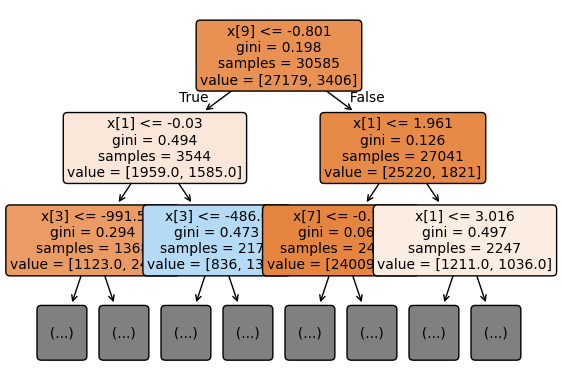

In [23]:
# decision tree plot
from sklearn.tree import plot_tree
tree.fit(x_train_prep, y_train)
plot_tree(tree, filled=True, rounded=True,max_depth=2,fontsize=10)
plt.show()

In [24]:
# Se obtiene la matriz de confusión para el modelo
from sklearn.metrics import confusion_matrix

y_pred = tree.predict(x_test_prep)
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[6339  457]
 [ 391  460]]


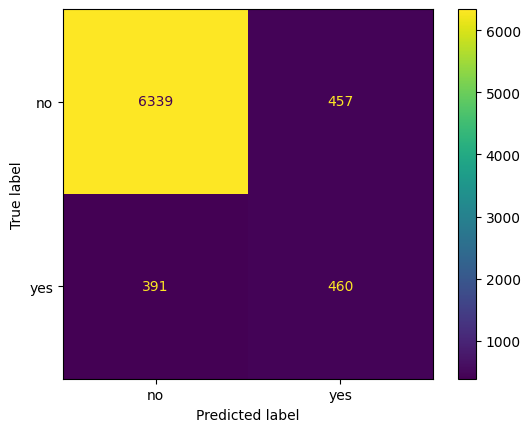

In [25]:
# Se visualiza la matriz de confusión
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes'])
disp.plot()

---
Esta es la nueva celda que hace la invocacion al proceso con mlflow

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC

# Resultados
resultados = {}

# Método 1 : Regresión Logística
lr = LogisticRegression(C=1, penalty='l2', solver='liblinear', random_state=1, max_iter=100, tol=0.000000001)
model_lr, metrics_lr = cross_val_mlflow(lr, "Logistic Regression")
resultados['Logistic Regression'] = metrics_lr

# Método 2 : SVC
svc = LinearSVC(max_iter=10000, tol=0.001)
model_svc, metrics_svc = cross_val_mlflow(svc, "Linear SVC")
resultados['Linear SVC'] = metrics_svc

# Método 3 : KNN
knc = KNeighborsClassifier(n_neighbors=7)
model_knc, metrics_knc = cross_val_mlflow(knc, "K-Nearest Neighbors")
resultados['K-Nearest Neighbors'] = metrics_knc

# Método 4 : Decision Tree
tree = DecisionTreeClassifier()
model_tree, metrics_tree = cross_val_mlflow(tree, "Decision Tree Classifier")
resultados['Decision Tree Classifier'] = metrics_tree

Modelo Logistic Regression registrado en MLflow con ID de ejecución: 40015f9643304a3b9748812ab947b54f
Modelo Linear SVC registrado en MLflow con ID de ejecución: 3c6936218a0e420abe51b6cba17a62a8
Modelo K-Nearest Neighbors registrado en MLflow con ID de ejecución: a223a0d747fc47d5b0581416c0a64caa
Modelo Decision Tree Classifier registrado en MLflow con ID de ejecución: 43e22e7f536c4a03993d0a2d752ea358


A continuacion se realiza una comparacion de los modelos para seleccionar el que va a ser utilizado posteriormente:

In [55]:
df_comparacion = pd.DataFrame(resultados).T
df_comparacion = df_comparacion.round(4)
df_comparacion = df_comparacion.sort_values(by='test_f1', ascending=False)

print(df_comparacion)

print("\nEl mejor modelo basado en F1 en el conjunto de pruebas es:", df_comparacion.index[0])
print(f"Valor de F1 en test: {df_comparacion.iloc[0]['test_f1']}")
print(f"Valor de recall en test: {df_comparacion.iloc[0]['test_recall']}")

                          cv_f1_mean  cv_recall_mean  cv_precision_mean  \
Decision Tree Classifier      0.4935          0.4840             0.4957   
Linear SVC                    0.5014          0.5064             0.4966   
Logistic Regression           0.5051          0.5120             0.4985   
K-Nearest Neighbors           0.5078          0.5119             0.5037   

                          cv_accuracy_mean  test_f1  test_recall  \
Decision Tree Classifier            0.4989   0.1800       0.5123   
Linear SVC                          0.4965   0.1663       0.4371   
Logistic Regression                 0.4983   0.1644       0.4383   
K-Nearest Neighbors                 0.5037   0.1455       0.4007   

                          test_precision  test_accuracy  
Decision Tree Classifier          0.1092         0.4806  
Linear SVC                        0.1027         0.5122  
Logistic Regression               0.1011         0.5040  
K-Nearest Neighbors               0.0889         0.

#### Predicción con datos nuevos (sin clasificar)

In [27]:

df_nuevos = pd.read_csv('../data/raw/bank-additional-new.csv')
df_nuevos.head(5)

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,contacted_before
0,56,housemaid,married,basic.4y,no,no,telephone,may,mon,261,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,NaN
1,57,services,married,high.school,no,no,telephone,may,mon,149,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,NaN
2,37,services,married,high.school,yes,no,telephone,may,mon,226,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,NaN
3,40,admin.,married,basic.6y,no,no,telephone,may,mon,151,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,NaN
4,56,services,married,high.school,no,yes,telephone,may,mon,307,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,NaN


In [28]:
# Diagnosticar el problema con los nuevos datos
print("Información del conjunto de datos nuevos:")
print(f"Forma: {df_nuevos.shape}")
print("\nTipos de datos:")
print(df_nuevos.dtypes)
print("\nValores nulos:")
print(df_nuevos.isnull().sum())
print("\nColumnas categóricas en nuevos datos:")
print(df_nuevos.select_dtypes(include='object').columns.tolist())
print("\nColumnas numéricas en nuevos datos:")
print(df_nuevos.select_dtypes(exclude='object').columns.tolist())

Información del conjunto de datos nuevos:
Forma: (9, 20)

Tipos de datos:
age                   int64
job                  object
marital              object
education            object
housing              object
loan                 object
contact              object
month                object
day_of_week          object
duration              int64
campaign              int64
previous              int64
poutcome             object
emp_var_rate        float64
cons_price_idx      float64
cons_conf_idx       float64
euribor3m           float64
nr_employed         float64
y                    object
contacted_before    float64
dtype: object

Valores nulos:
age                 0
job                 0
marital             0
education           0
housing             0
loan                0
contact             0
month               0
day_of_week         0
duration            0
campaign            0
previous            0
poutcome            0
emp_var_rate        0
cons_price_idx      0
cons_c

In [29]:
# Comparar con los datos de entrenamiento originales
print("Comparación de columnas:")
print(f"Columnas en datos originales: {list(X.columns)}")
print(f"Columnas en datos nuevos: {list(df_nuevos.columns)}")

print("\nColumnas que están en nuevos pero no en originales:")
new_cols = set(df_nuevos.columns) - set(X.columns)
print(new_cols)

print("\nColumnas que están en originales pero no en nuevos:")
missing_cols = set(X.columns) - set(df_nuevos.columns)
print(missing_cols)

Comparación de columnas:
Columnas en datos originales: ['age', 'job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed']
Columnas en datos nuevos: ['age', 'job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y', 'contacted_before']

Columnas que están en nuevos pero no en originales:
{'contacted_before', 'y'}

Columnas que están en originales pero no en nuevos:
{'pdays'}


In [31]:
# Se hace la predicción con los nuevos datos
# Primero, eliminar la columna objetivo si existe y preparar las características
X_new = df_nuevos.drop('y', axis=1) if 'y' in df_nuevos.columns else df_nuevos.copy()

# Asegurar que las columnas estén en el mismo orden que en el entrenamiento
X_new = X_new[X.columns]

# Manejar la columna contacted_before para que coincida con el formato de entrenamiento
# En entrenamiento: 'no', 'yes' (string)
# En nuevos datos: NaN -> necesita convertirse a 'no' (asumiendo que NaN significa no contactado)
X_new['contacted_before'] = X_new['contacted_before'].fillna('no')

# Convertir cualquier valor numérico a string si es necesario
if X_new['contacted_before'].dtype in ['float64', 'int64']:
    X_new['contacted_before'] = X_new['contacted_before'].map({0.0: 'no', 1.0: 'yes'}).fillna('no')

# Asegurar que contacted_before sea de tipo object como en entrenamiento
X_new['contacted_before'] = X_new['contacted_before'].astype('object')

# Transformar los nuevos datos usando el mismo preprocesador y predecir
try:
    x_new_prep = preprocessor_full.transform(X_new)
    
    y_new_pred = tree.predict(x_new_prep)
    print(f"\nPredicciones: {y_new_pred}")
    
    predictions_df = pd.DataFrame({
        'Cliente': range(1, len(y_new_pred) + 1),
        'Predicción_Numérica': y_new_pred,
        'Suscribirá': ['No' if pred == 0 else 'Sí' for pred in y_new_pred]
    })
    print("\nResultados detallados:")
    print(predictions_df.to_string(index=False))
    
    # Resumen de predicciones
    pred_counts = pd.Series(y_new_pred).value_counts()
    print("\nResumen de predicciones:")
    for pred_val, count in pred_counts.items():
        label = 'No realizará un depósito' if pred_val == 0 else 'Sí realizará un depósito'
        print(f"  {label}: {count} clientes ({count/len(y_new_pred)*100:.1f}%)")
    
except Exception as e:
    print(f"Error durante el preprocesamiento o predicción: {e}")
    print("Información adicional para depuración:")
    print(f"Tipos de datos en X_new:\n{X_new.dtypes}")

KeyError: "['pdays'] not in index"